# Student Performance Prediction

## Project Overview

This project aims to predict students' mathematics scores using demographic and academic factors such as gender, parental education level, lunch type, test preparation course, reading score, and writing score.

A Machine Learning regression approach using Linear Regression is implemented to estimate student performance and identify the key factors affecting mathematics scores.

The project follows a complete Machine Learning workflow including data preprocessing, exploratory data analysis (EDA), feature engineering, categorical encoding, model training, evaluation, feature importance analysis, and model saving.

In [490]:
import pandas as pd
import numpy as np

## 1. Importing Libraries

In [491]:
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


### Dataset Description

The dataset contains information about students' demographic background and academic performance.

It includes features such as gender, parental education level, lunch type, test preparation course, reading score, writing score, and the target variable (math score).

The dataset contains 1000 student records with 8 original features.

## 2. Loading the Dataset & Dataset Overview

In [492]:
df = pd.read_csv("../Dataset/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [493]:
df.shape

(1000, 8)

In [494]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [495]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Data Cleaning and Validation

In [496]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [497]:
df.duplicated().sum()

np.int64(0)

In [498]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

## 4. Feature Engineering

In [499]:
df["average_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
) / 3


df["test_prep_completed"] = (
    df["test_preparation_course"] == "completed"
).astype(int)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,test_prep_completed
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,0


In [500]:
df[['math_score','reading_score','writing_score']].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [501]:
(df[['math_score','reading_score','writing_score']] >= 0).all()

math_score       True
reading_score    True
writing_score    True
dtype: bool

In [502]:
(df[['math_score','reading_score','writing_score']] <= 100).all()

math_score       True
reading_score    True
writing_score    True
dtype: bool

## 5. Exploratory Data Analysis (EDA)

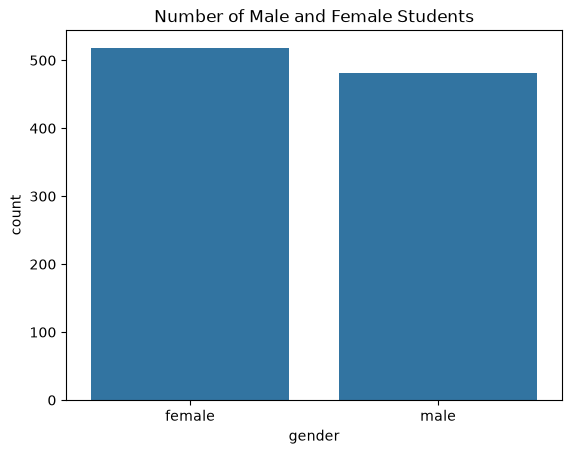

In [503]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="gender", data=df)
plt.title("Number of Male and Female Students")
plt.savefig("../Images/gender_distribution.png")
plt.show()

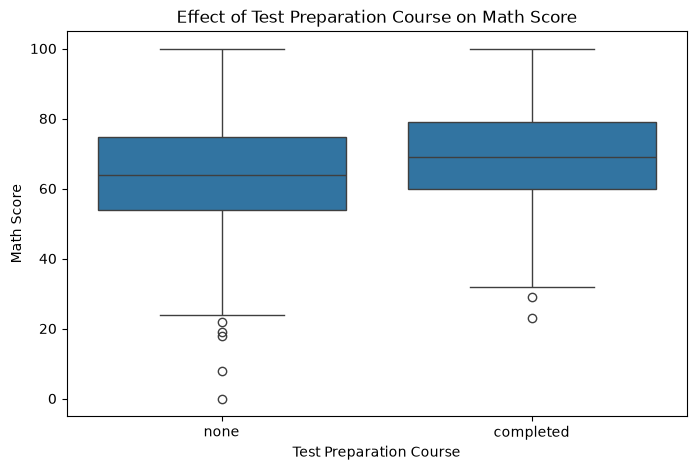

In [504]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="test_preparation_course",
    y="math_score",
    data=df
)

plt.title("Effect of Test Preparation Course on Math Score")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

plt.savefig("../Images/test_preparation_boxplot.png")

plt.show()

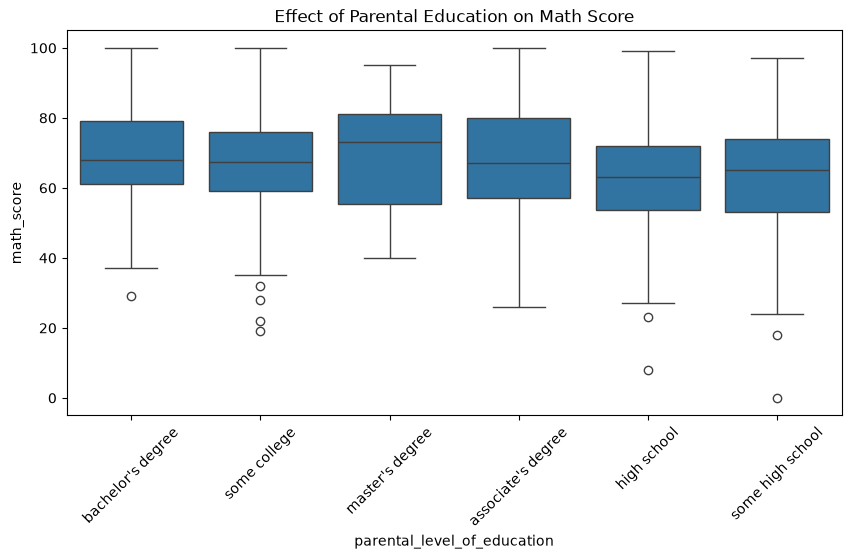

In [505]:
plt.figure(figsize=(10,5))

sns.boxplot(x="parental_level_of_education", 
            y="math_score", 
            data=df)

plt.xticks(rotation=45)
plt.title("Effect of Parental Education on Math Score")
plt.show()

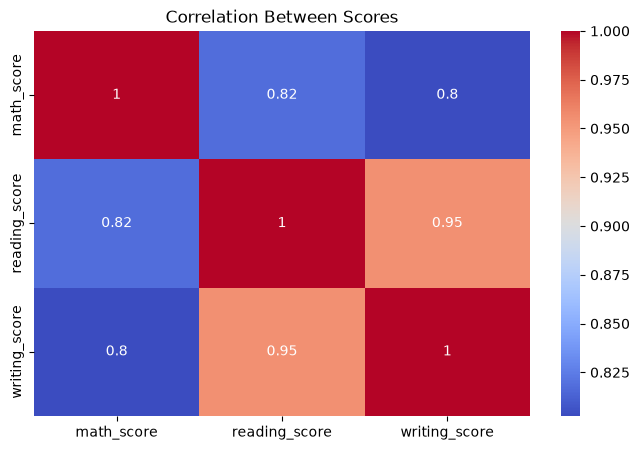

In [506]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['math_score','reading_score','writing_score']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Scores")
plt.savefig("../Images/correlation_heatmap.png")
plt.show()

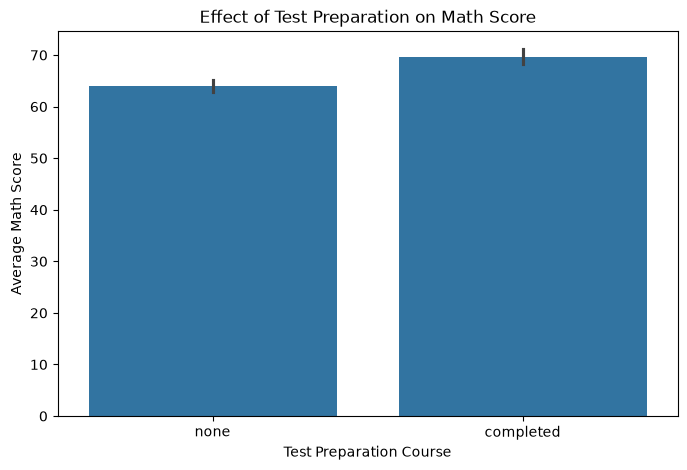

In [507]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="test_preparation_course",
    y="math_score"
)

plt.title("Effect of Test Preparation on Math Score")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Math Score")

plt.savefig("../Images/test_preparation.png")

plt.show()

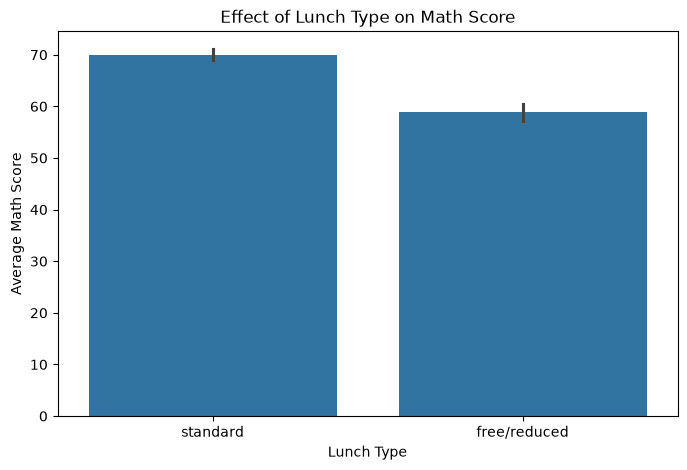

In [508]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="lunch",
    y="math_score"
)

plt.title("Effect of Lunch Type on Math Score")
plt.xlabel("Lunch Type")
plt.ylabel("Average Math Score")

plt.savefig("../Images/lunch_vs_math_score.png")

plt.show()

### EDA Insights

1. Students who completed the test preparation course achieved higher average math scores compared to students who did not complete it.

2. Students with standard lunch generally performed better than students with free/reduced lunch.

3. Reading and writing scores show a strong positive relationship with math scores, indicating that students performing well in one subject tend to perform well in others.

4. Parental education level shows some influence on student performance, with higher education levels generally associated with better scores.

In [509]:
df.select_dtypes(include="string").columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')

In [510]:
for col in df.select_dtypes(include="string").columns:
    print(col)
    print(df[col].unique())
    print("----------------")

gender
<StringArray>
['female', 'male']
Length: 2, dtype: str
----------------
race_ethnicity
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
----------------
parental_level_of_education
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
----------------
lunch
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
----------------
test_preparation_course
<StringArray>
['none', 'completed']
Length: 2, dtype: str
----------------


In [511]:
df_model = df.drop("average_score", axis=1)
df_model.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,test_prep_completed
0,female,group B,bachelor's degree,standard,none,72,72,74,0
1,female,group C,some college,standard,completed,69,90,88,1
2,female,group B,master's degree,standard,none,90,95,93,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,0
4,male,group C,some college,standard,none,76,78,75,0


## 6. Data Encoding

In [512]:
df_encoded = pd.get_dummies(df_model, drop_first=True)
df_encoded.head()

,math_score,reading_score,writing_score,test_prep_completed,gender_male,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,72,74,0,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,1,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,0,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,0,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,0,True,False,True,False,False,False,False,False,True,False,True,True


In [513]:
df_encoded.shape

(1000, 16)

In [514]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   math_score                                     1000 non-null   int64
 1   reading_score                                  1000 non-null   int64
 2   writing_score                                  1000 non-null   int64
 3   test_prep_completed                            1000 non-null   int64
 4   gender_male                                    1000 non-null   bool 
 5   race_ethnicity_group B                         1000 non-null   bool 
 6   race_ethnicity_group C                         1000 non-null   bool 
 7   race_ethnicity_group D                         1000 non-null   bool 
 8   race_ethnicity_group E                         1000 non-null   bool 
 9   parental_level_of_education_bachelor's degree  1000 non-null   bool 
 10  parental_lev

In [515]:
df_encoded = df_encoded.astype(int)
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   math_score                                     1000 non-null   int64
 1   reading_score                                  1000 non-null   int64
 2   writing_score                                  1000 non-null   int64
 3   test_prep_completed                            1000 non-null   int64
 4   gender_male                                    1000 non-null   int64
 5   race_ethnicity_group B                         1000 non-null   int64
 6   race_ethnicity_group C                         1000 non-null   int64
 7   race_ethnicity_group D                         1000 non-null   int64
 8   race_ethnicity_group E                         1000 non-null   int64
 9   parental_level_of_education_bachelor's degree  1000 non-null   int64
 10  parental_lev

## 7. Feature Selection

In [516]:
X = df_encoded.drop("math_score", axis=1)
y = df_encoded["math_score"]

print(X.shape)
print(y.shape)

(1000, 15)
(1000,)


## 8. Train-Test Split

In [517]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 15)
(200, 15)
(800,)
(200,)


## 9. Model Building

In [518]:
from sklearn.linear_model import LinearRegression

In [519]:
model = LinearRegression()

In [520]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0.24, 0.72,-1.64,..., 0.76, 3.51, 1.64]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['reading_score','writing_score','test_prep_completed',..., 'parental_level_of_education_some high school','lunch_standard', 'test_preparation_course_none']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.268
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14


In [521]:
y_pred = model.predict(X_test)

y_pred[:5]

array([76.3879697 , 58.88597004, 76.99026483, 76.85180448, 87.62737816])

### Actual vs Predicted Values

This scatter plot compares the actual mathematics scores with the scores predicted by the Linear Regression model.

Points closer to the actual values indicate better prediction performance. The visualization helps evaluate how well the model predictions match the real student scores.

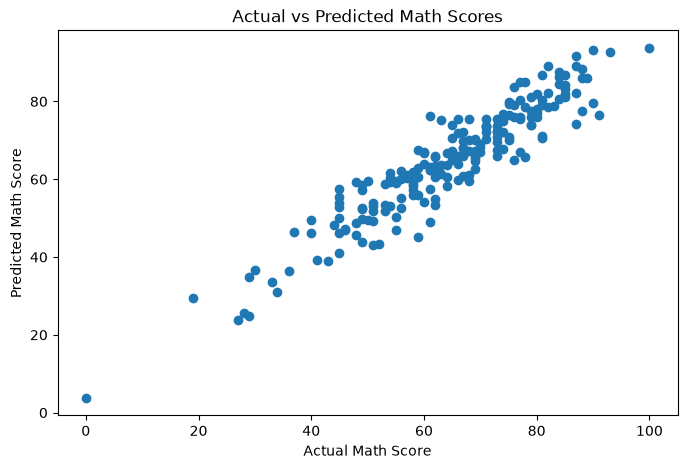

In [522]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")

plt.savefig("../Images/actual_vs_predicted.png")

plt.show()

## 10. Model Evaluation

In [523]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.214763142474848
MSE: 29.095169866715487
RMSE: 5.393993869732843
R2 Score: 0.8804332983749565


### Evaluation Metrics Interpretation

The Linear Regression model was evaluated using MAE, MSE, RMSE, and R² Score.

- **MAE (Mean Absolute Error):** Represents the average difference between actual and predicted math scores. Lower MAE indicates better predictions.

- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted values. It gives higher importance to larger errors.

- **RMSE (Root Mean Squared Error):** Represents prediction error in the same unit as the target variable (math score). A lower RMSE indicates that predictions are closer to actual values.

- **R² Score:** Shows how much variation in the target variable is explained by the model. The model achieved an R² score of approximately 0.88, meaning it explains around 88% of the variation in students' math scores.

## 11. Feature Importance Analysis

In [524]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
3,gender_male,13.064884
7,race_ethnicity_group E,4.892649
13,lunch_standard,3.510075
14,test_preparation_course_none,1.644821
11,parental_level_of_education_some college,0.998856
9,parental_level_of_education_high school,0.929312
12,parental_level_of_education_some high school,0.756470
1,writing_score,0.724148
4,race_ethnicity_group B,0.359323
0,reading_score,0.236023


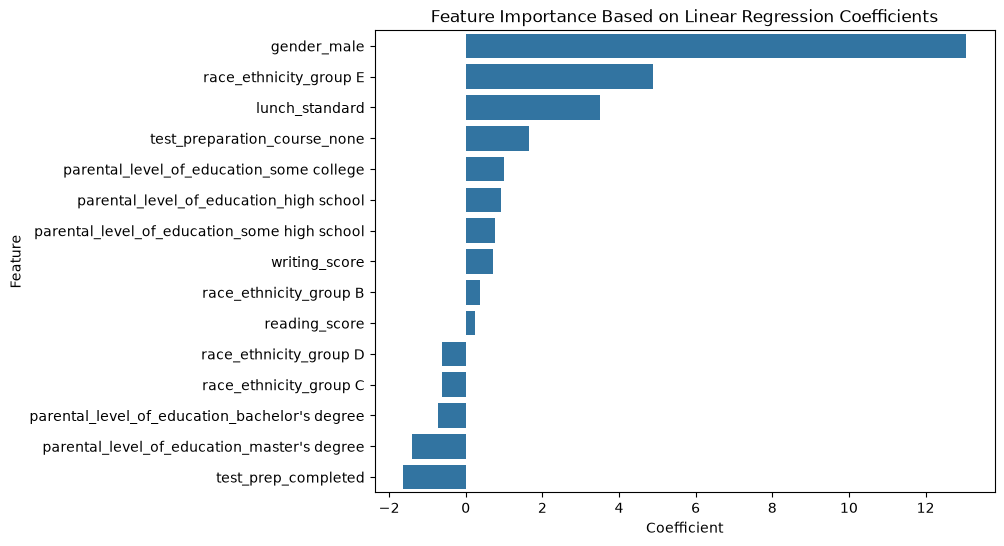

In [525]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance Based on Linear Regression Coefficients")
plt.savefig("../Images/feature_importance.png")
plt.show()

### Feature Importance Insights

The Linear Regression coefficients help identify which factors have the strongest influence on predicting students' mathematics scores.

### Key Findings:

- Academic performance indicators such as reading and writing scores show a positive relationship with mathematics scores, suggesting that students who perform well in other subjects are likely to perform better in mathematics.

- Test preparation course is an important factor associated with student performance. The coefficient values should be interpreted relative to the baseline category created during one-hot encoding.

- Lunch type shows an association with performance, where students receiving standard lunch generally demonstrate better academic outcomes compared to students with free/reduced lunch.

- Parental education level shows some impact on student performance, indicating that family educational background can influence learning support and academic achievement.

Overall, academic factors such as reading and writing ability are among the strongest indicators for predicting mathematics performance.

## 12. Saving the Trained Model

In [526]:
import pickle

with open("../student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Conclusion

This project successfully developed a Machine Learning model to predict students' mathematics scores using demographic and academic factors.

The complete workflow included data cleaning, exploratory data analysis, feature engineering, categorical data encoding, model training, and evaluation.

The Linear Regression model achieved an R² score of approximately 0.88, showing strong predictive performance.

The analysis revealed that academic indicators such as reading and writing scores have a strong relationship with mathematics performance. Other factors such as test preparation, lunch type, and parental education also influence student outcomes.

This project demonstrates how Machine Learning can be used to analyze educational data and identify important factors affecting student performance.